# Обзор методов классификации в scikit-learn на датасете Iris

Рассмотрим три метода классификации из библиотеки scikit-learn:
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

In [18]:
# Библиотека pandas нужна для работы с таблицами и CSV-файлами
import pandas as pd

# Библиотека matplotlib нужна для построения графиков
import matplotlib.pyplot as plt

# Функция для разделения данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Инструмент для масштабирования признаков
from sklearn.preprocessing import StandardScaler

# Метрики для оценки качества моделей
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Модель логистической регрессии
from sklearn.linear_model import LogisticRegression

# Модель дерева решений и функция для его визуализации
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Модель случайного леса
from sklearn.ensemble import RandomForestClassifier

In [19]:
# Загружаем датасет из CSV-файла в таблицу pandas
df = pd.read_csv("Iris.csv")

# Показываем первые 5 строк таблицы
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [20]:
# Структура датасета. Выводим краткую информацию о таблице:
# количество строк, названия столбцов, типы данных, наличие пропусков
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [21]:
# Статистические характеристики признаков. Выводим описательную статистику по числовым признакам:
# среднее значение, минимум, максимум и другие показатели
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [22]:
# Считаем, сколько объектов относится к каждому виду ириса
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

По результатам первичного анализа видно, что датасет содержит числовые признаки, описывающие размеры чашелистиков и лепестков ириса, а также категориальный столбец Species, который является целевой переменной. В данном случае требуется по значениям признаков растения определить его принадлежность к одному из видов ириса, поэтому задача относится к классификации.

## Подготовка данных

Удалим лишний столбец Id, затем разделим данные на признаки и целевую переменную. После этого разобьём выборку на обучающую (данные, на которых модель учится) и тестовую (данные, на которых мы проверяем, как модель работает на новых объектах, которых она раньше не видела).

In [23]:
# Удаляем столбец Id, так как он не несёт полезной информации для классификации
df = df.drop(columns=["Id"])

# X — это признаки, по которым модель будет определять вид ириса
X = df.drop(columns=["Species"])

# y — это целевая переменная, то есть правильные ответы
y = df["Species"]

# Выводим первые строки признаков
print("Признаки:")
print(X.head())

# Выводим первые значения целевой переменной
print("\nЦелевая переменная:")
print(y.head())

Признаки:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Целевая переменная:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: str


In [24]:
# Делим данные на обучающую и тестовую выборки
# test_size=0.2 означает, что 20% данных пойдут на тест
# random_state=42 фиксирует случайность
# stratify=y сохраняет пропорции классов в обеих выборках
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Показываем размеры получившихся выборок
print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (120, 4)
Размер тестовой выборки: (30, 4)


In [25]:
# Создаём объект для масштабирования данных
scaler = StandardScaler()

# Вычисляем параметры масштабирования по обучающей выборке
# и сразу преобразуем обучающие данные
X_train_scaled = scaler.fit_transform(X_train)

# Преобразуем тестовые данные с теми же параметрами
X_test_scaled = scaler.transform(X_test)

## 1. Logistic Regression

Логистическая регрессия относится к линейным моделям и применяется для решения задач классификации. Она хорошо подходит в качестве базовой модели, поскольку проста в использовании, быстро обучается и позволяет получить интерпретируемый результат.

In [26]:
# Создаём модель логистической регрессии
# max_iter=200 задаёт максимальное число итераций обучения
log_reg = LogisticRegression(max_iter=200)

# Обучаем модель на масштабированных обучающих данных
log_reg.fit(X_train_scaled, y_train)

# Получаем предсказания на тестовой выборке
y_pred_log = log_reg.predict(X_test_scaled)

# Выводим результаты работы модели
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log)) # какую долю объектов модель классифицировала правильно

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_log)) # таблица, где качество модели показано по каждому классу отдельно

print("Confusion matrix:\n")
print(confusion_matrix(y_test, y_pred_log)) # матрица ошибок - сколько объектов каждого настоящего класса модель отнесла к каждому предсказанному классу

Logistic Regression
Accuracy: 0.9333333333333333

Classification report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Confusion matrix:

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


Логистическая регрессия показала себя как простая и удобная базовая модель для решения задачи классификации. Её преимуществами являются высокая скорость работы, понятность и хорошая интерпретируемость результатов.

Логистическая регрессия показала точность 93.3%, то есть правильно классифицировала 28 объектов из 30. Согласно матрице ошибок, все объекты класса Iris-setosa были распознаны верно, а ошибки возникли только между классами Iris-versicolor и Iris-virginica: один объект versicolor был отнесён к virginica, и один объект virginica — к versicolor. Это говорит о том, что модель хорошо распознаёт наиболее отделимый класс и допускает небольшие ошибки между более похожими классами.

## 2. Decision Tree Classifier

Дерево решений — это модель, которая последовательно разделяет объекты по значениям признаков. Основным преимуществом данного метода является наглядность, поскольку процесс принятия решений можно представить в виде схемы.

In [27]:
# Создаём модель дерева решений
# max_depth=3 ограничивает глубину дерева и помогает уменьшить переобучение
tree_clf = DecisionTreeClassifier(random_state=42, max_depth=3)

# Обучаем дерево решений на обучающей выборке
tree_clf.fit(X_train, y_train)

# Получаем предсказания на тестовой выборке
y_pred_tree = tree_clf.predict(X_test)

# Выводим результаты работы модели
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_tree)) #общая точность модели

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_tree)) # таблица, где качество модели показано по каждому классу отдельно

print("Confusion matrix:\n")
print(confusion_matrix(y_test, y_pred_tree)) # матрица ошибок - сколько объектов каждого настоящего класса модель отнесла к каждому предсказанному классу

Decision Tree
Accuracy: 0.9666666666666667

Classification report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

Confusion matrix:

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


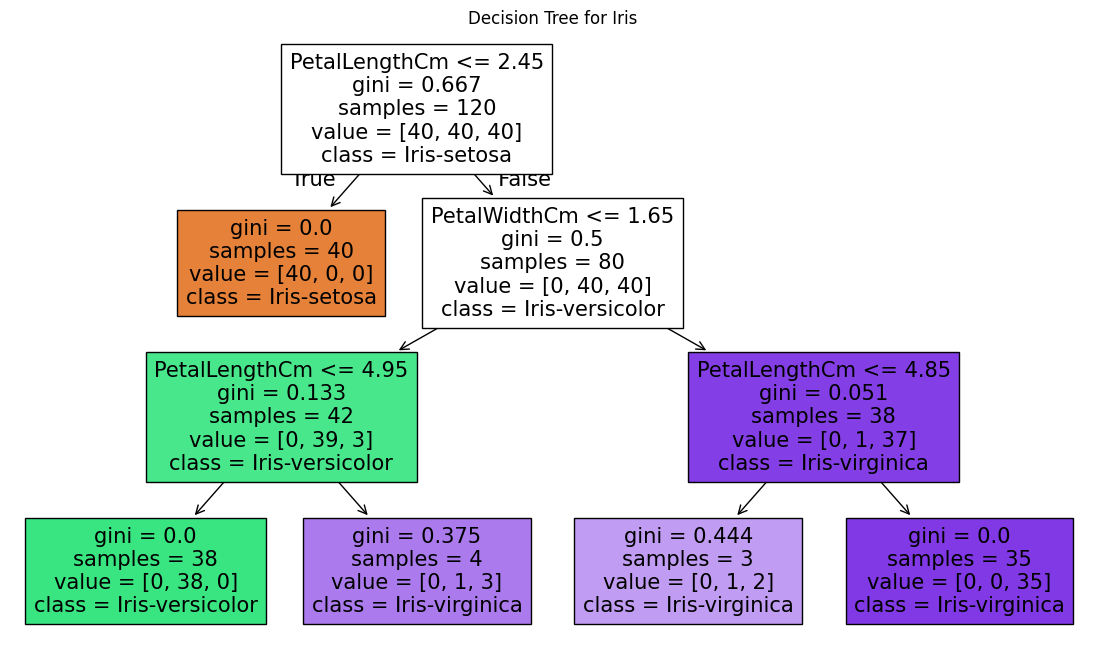

In [28]:
# Создаём область для построения рисунка
plt.figure(figsize=(14, 8))

# Визуализируем дерево решений
plot_tree(
    tree_clf,                    # обученная модель дерева
    feature_names=X.columns,     # названия признаков
    class_names=tree_clf.classes_,  # названия классов
    filled=True                  # закрашиваем узлы цветом
)

# Добавляем заголовок
plt.title("Decision Tree for Iris")

# Показываем рисунок
plt.show()

Дерево решений позволяет наглядно увидеть, по каким признакам модель разделяет объекты на классы. Это делает метод удобным для интерпретации, однако без ограничения глубины дерево может переобучаться.

Decision Tree показал точность 96.7%, то есть правильно классифицировал 29 объектов из 30. Согласно матрице ошибок, все объекты классов Iris-setosa и Iris-virginica были распознаны верно, а единственная ошибка возникла для класса Iris-versicolor: один объект этого класса был отнесён к Iris-virginica. Это говорит о том, что дерево решений очень хорошо разделяет классы на данном датасете и допускает лишь незначительные ошибки между наиболее похожими видами.

## 3. Random Forest Classifier

Случайный лес представляет собой ансамбль деревьев решений. Он объединяет результаты нескольких деревьев, благодаря чему модель становится более устойчивой и часто показывает более высокое качество классификации.

In [29]:
# Создаём модель случайного леса
# n_estimators=100 означает, что будет построено 100 деревьев
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Обучаем модель на обучающей выборке
rf_clf.fit(X_train, y_train)

# Получаем предсказания на тестовой выборке
y_pred_rf = rf_clf.predict(X_test)

# Выводим результаты работы модели
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf)) # общая точность модели

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_rf))

print("Confusion matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9

Classification report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30

Confusion matrix:

[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


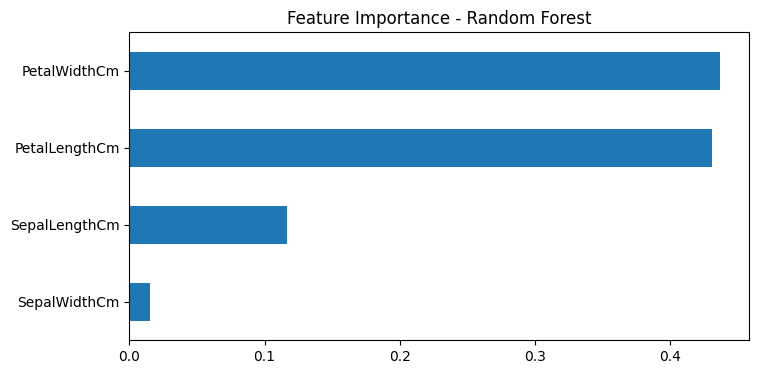

In [30]:
# Создаём таблицу важности признаков - график, который показывает, какие признаки были для модели наиболее полезными при принятии решений
importance = pd.Series(rf_clf.feature_importances_, index=X.columns)

# Сортируем важности и строим горизонтальный столбчатый график
importance.sort_values().plot(kind="barh", figsize=(8, 4))

# Добавляем заголовок графика
plt.title("Feature Importance - Random Forest")

# Показываем график
plt.show()

Random Forest показал точность 90%, то есть правильно классифицировал 27 объектов из 30. Согласно матрице ошибок, все объекты класса Iris-setosa были распознаны верно, однако ошибки возникли при различении классов Iris-versicolor и Iris-virginica: один объект Iris-versicolor был отнесён к Iris-virginica, а два объекта Iris-virginica — к Iris-versicolor. Это показывает, что модель уверенно распознаёт наиболее хорошо отделимый класс, но испытывает больше трудностей при различении схожих между собой видов.

Важность признака показывает, насколько сильно этот признак помогал модели различать классы.
На Iris самыми важными оказались признаки, связанные с лепестками: PetalLengthCm, PetalWidthCm. А признаки чашелистика часто оказались менее важными.
Это означает, что для различения видов ириса размеры лепестков обычно полезнее, чем размеры чашелистиков.

## Сравнение результатов моделей

In [32]:
# Создаём таблицу со сравнением точности всех моделей
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ]
})

# Выводим таблицу
results

,Model,Accuracy
0,Logistic Regression,0.933333
1,Decision Tree,0.966667
2,Random Forest,0.900000


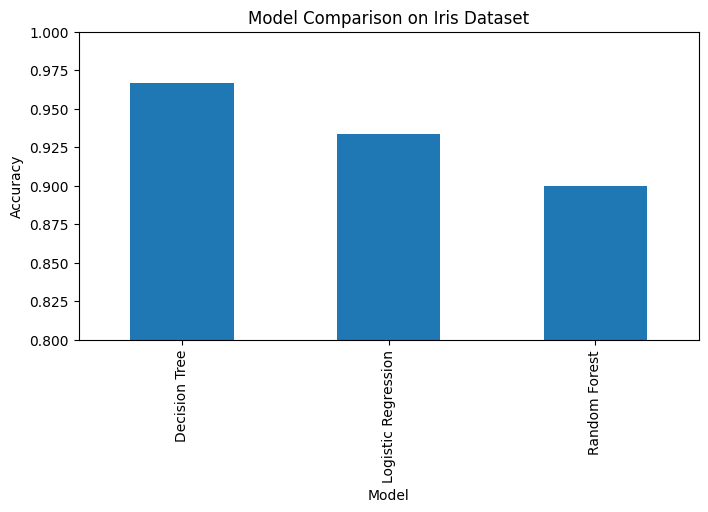

In [33]:
# Сортируем модели по точности и строим столбчатую диаграмму
results.sort_values("Accuracy", ascending=False).plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    figsize=(8, 4)
)

# Ограничиваем диапазон оси Y для наглядности
plt.ylim(0.8, 1.0)

# Добавляем заголовок и подпись оси Y
plt.title("Model Comparison on Iris Dataset")
plt.ylabel("Accuracy")

# Показываем график
plt.show()

## Вывод

В работе были рассмотрены три метода классификации из библиотеки scikit-learn: Logistic Regression, Decision Tree Classifier и Random Forest Classifier.

По результатам эксперимента наилучшую точность показало дерево решений — 96.7%, что соответствует 29 правильным ответам из 30. Логистическая регрессия показала точность 93.3% и допустила 2 ошибки. Случайный лес продемонстрировал точность 90% и допустил 3 ошибки. Во всех трёх моделях класс Iris-setosa был распознан без ошибок, тогда как основные затруднения возникали при различении классов Iris-versicolor и Iris-virginica, которые обладают более схожими признаками.